<a href="https://colab.research.google.com/github/Vennela0229/2520030288_OS-practical/blob/main/Experiment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab/placement_predict_50k_adjusted.csv"

In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (50000, 21)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


In [ ]:
NUMERIC_COLS = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
]

CATEGORICAL_COLS = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular",
]

print("Numeric columns:", len(NUMERIC_COLS))
print("Categorical columns:", len(CATEGORICAL_COLS))

Numeric columns: 11
Categorical columns: 8


In [ ]:
missing_numeric = [col for col in NUMERIC_COLS if col not in df.columns]
missing_categorical = [col for col in CATEGORICAL_COLS if col not in df.columns]

print("Missing numeric columns:", missing_numeric)
print("Missing categorical columns:", missing_categorical)

print("\nDataset columns:")
print(df.columns.tolist())

Missing numeric columns: []
Missing categorical columns: []

Dataset columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']


In [ ]:
imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS,
    index=df.index
)

cat_df = pd.get_dummies(
    df[CATEGORICAL_COLS],
    drop_first=True
)

feature_df = pd.concat([num_df, cat_df], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

print(f"Loaded {len(df):,} students")
print(f"Number of clustering features: {feature_df.shape[1]}")
print("PlacementStatus excluded from clustering.")

Loaded 50,000 students
Number of clustering features: 33
PlacementStatus excluded from clustering.


In [ ]:
k_range = range(2, 9)

sample_size = min(5000, len(X))

sil_sample_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    sample_size,
    replace=False
)

X_sil_sample = X[sil_sample_idx]

inertias = []
sil_scores = []

for k in k_range:

    km_k = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels_k = km_k.fit_predict(X)

    inertias.append(km_k.inertia_)

    sil_scores.append(
        silhouette_score(
            X_sil_sample,
            km_k.predict(X_sil_sample)
        )
    )

print("K-Means evaluation completed.")

K-Means evaluation completed.


In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4.5)
)

ax1.plot(
    list(k_range),
    inertias,
    marker="o"
)

ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")


ax2.plot(
    list(k_range),
    sil_scores,
    marker="o"
)

ax2.set_title("Silhouette Score vs k")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [ ]:
best_k = list(k_range)[
    int(np.argmax(sil_scores))
]

print("Silhouette-suggested K:", best_k)

print("\nSilhouette scores:")

for k, score in zip(k_range, sil_scores):
    print(f"k={k}: {score:.3f}")

Silhouette-suggested K: 2

Silhouette scores:
k=2: 0.144
k=3: 0.078
k=4: 0.073
k=5: 0.053
k=6: 0.081
k=7: 0.095
k=8: 0.102


In [ ]:
kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE
)

km_labels = kmeans.fit_predict(X)

sil = silhouette_score(
    X[sil_sample_idx],
    km_labels[sil_sample_idx]
)

print(f"K-Means K = {best_k}")
print(f"Silhouette Score = {sil:.3f}")

print("\nCluster sizes:")
print(
    pd.Series(km_labels)
    .value_counts()
    .sort_index()
)

K-Means K = 2
Silhouette Score = 0.144

Cluster sizes:
0    26429
1    23571
Name: count, dtype: int64


In [ ]:
profiled = feature_df.copy()

profiled["KMeansCluster"] = km_labels

profiled["PlacementStatus"] = df[
    "PlacementStatus"
].values

summary = profiled.groupby(
    "KMeansCluster"
).agg(

    n_students=("PlacementStatus", "size"),

    placement_rate=("PlacementStatus", "mean"),

    avg_CGPA=("CGPA", "mean"),

    avg_AttendancePercent=(
        "AttendancePercent",
        "mean"
    ),

    avg_AptitudeTestScore=(
        "AptitudeTestScore",
        "mean"
    ),

    avg_SoftSkillsRating=(
        "SoftSkillsRating",
        "mean"
    ),

    avg_CodingTestScore=(
        "CodingTestScore",
        "mean"
    ),

    avg_MockInterviewScore=(
        "MockInterviewScore",
        "mean"
    ),

    avg_Internships=("Internships", "mean"),

    avg_Projects=("Projects", "mean")
).round(3)

print(summary)

               n_students  placement_rate  avg_CGPA  avg_AttendancePercent  \
KMeansCluster                                                                
0                   26429           0.202     6.558                 67.338   
1                   23571           0.781     8.131                 83.340   

               avg_AptitudeTestScore  avg_SoftSkillsRating  \
KMeansCluster                                                
0                             54.559                 5.444   
1                             76.411                 7.658   

               avg_CodingTestScore  avg_MockInterviewScore  avg_Internships  \
KMeansCluster                                                                 
0                           47.260                  54.743            0.621   
1                           74.035                  76.239            1.978   

               avg_Projects  
KMeansCluster                
0                     1.556  
1                     3.628  


In [ ]:
summary.to_csv(
    "/content/drive/MyDrive/cluster_profiles.csv"
)

print("Saved:")
print("/content/drive/MyDrive/cluster_profiles.csv")

Saved:
/content/drive/MyDrive/cluster_profiles.csv


In [ ]:
sub_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    min(5000, len(X)),
    replace=False
)

X_sub = X[sub_idx]

print("Subsample size:", len(X_sub))

Subsample size: 5000


In [ ]:
hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hc_labels = hc.fit_predict(X_sub)

sil_hc = silhouette_score(
    X_sub,
    hc_labels
)

print(
    f"Hierarchical Clustering "
    f"silhouette: {sil_hc:.3f}"
)

Hierarchical Clustering silhouette: 0.114


In [ ]:
db = DBSCAN(
    eps=4.0,
    min_samples=15
)

db_labels = db.fit_predict(X_sub)

n_db_clusters = len(
    set(db_labels)
) - (1 if -1 in db_labels else 0)

n_noise = int(
    np.sum(db_labels == -1)
)

print(
    f"DBSCAN clusters: {n_db_clusters}"
)

print(
    f"DBSCAN noise points: {n_noise}"
)

if n_db_clusters >= 2:

    mask = db_labels != -1

    db_sil = silhouette_score(
        X_sub[mask],
        db_labels[mask]
    )

    print(
        f"DBSCAN silhouette: {db_sil:.3f}"
    )

DBSCAN clusters: 6
DBSCAN noise points: 2083
DBSCAN silhouette: -0.064


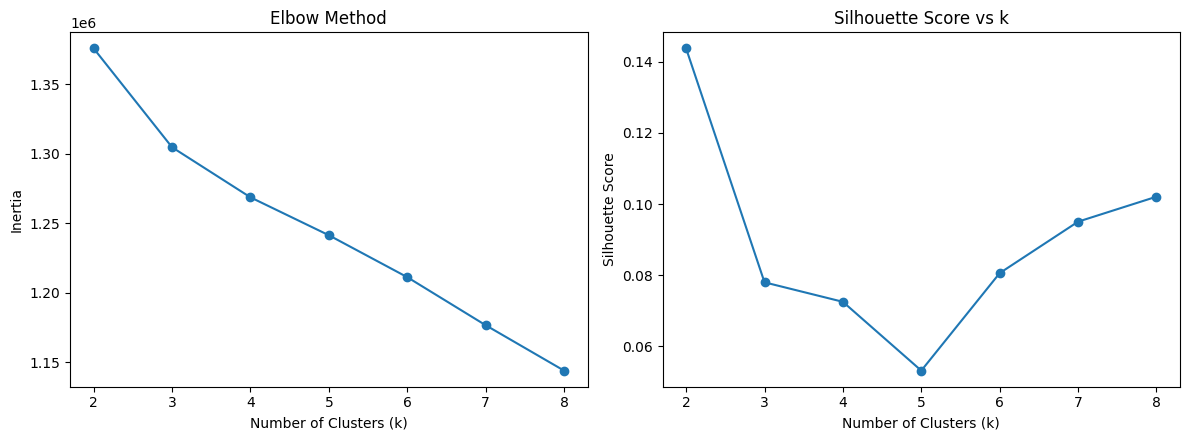

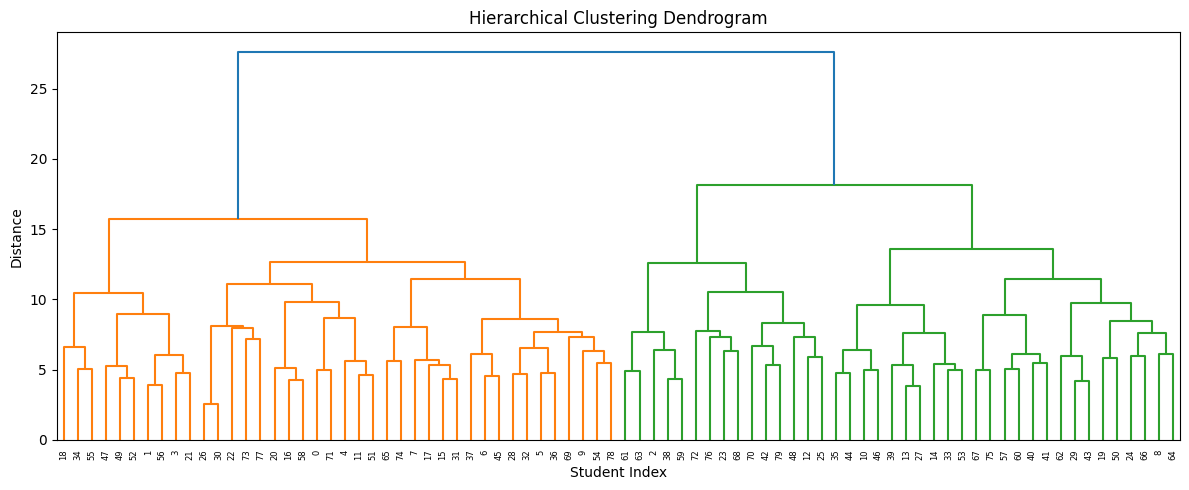

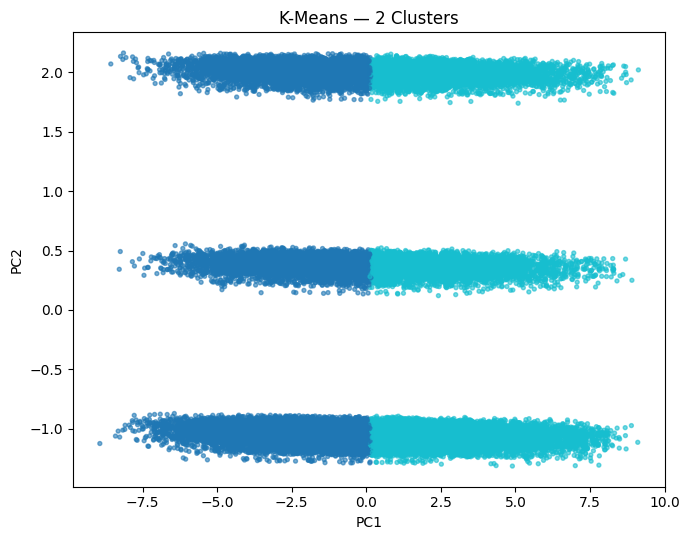

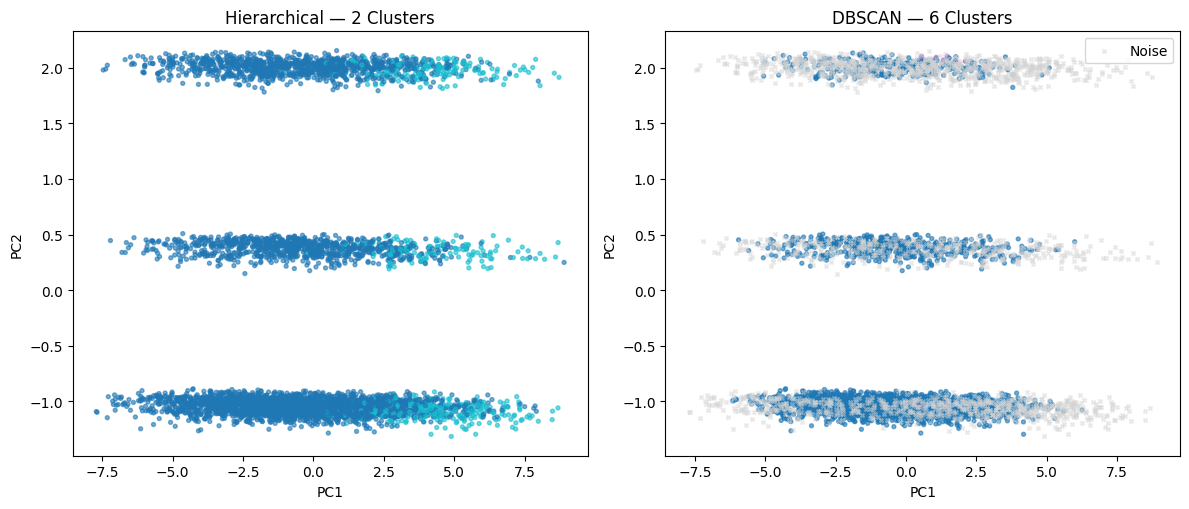

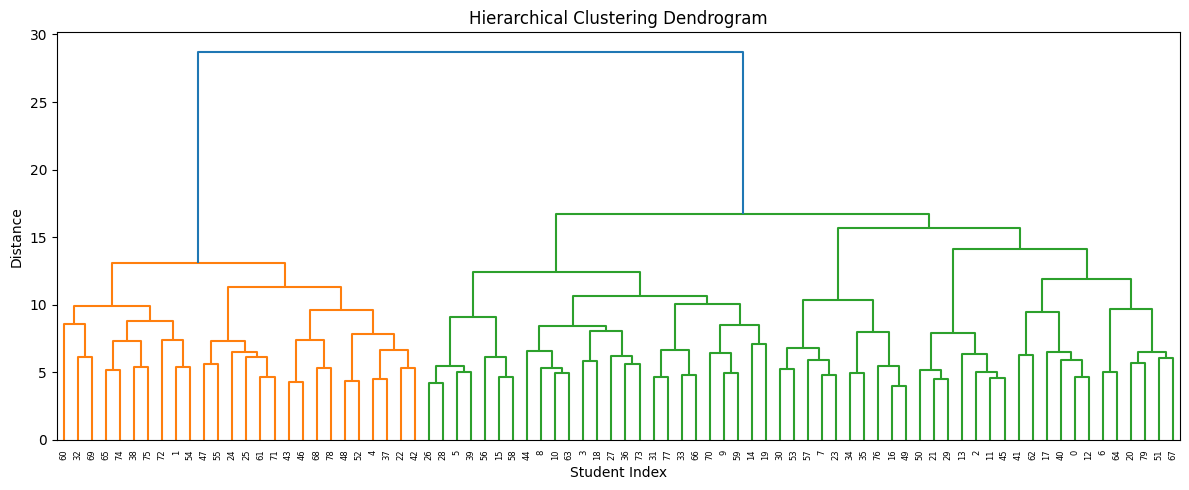

In [ ]:
dendro_idx = np.random.choice(
    len(X_sub),
    size=min(80, len(X_sub)),
    replace=False
)

Z = linkage(
    X_sub[dendro_idx],
    method="ward"
)

plt.figure(figsize=(12, 5))

dendrogram(Z)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Student Index")
plt.ylabel("Distance")

plt.tight_layout()

plt.show()

In [ ]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca_full = pca.fit_transform(X)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.2525452  0.04971866]
Total variance explained: 0.302263863853916


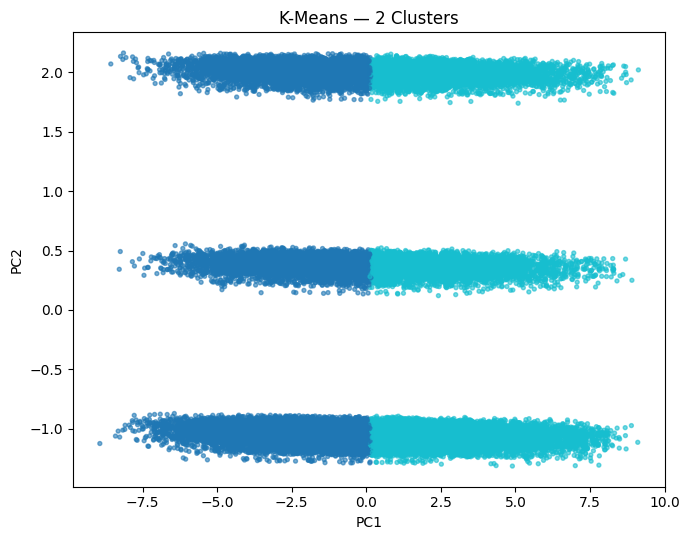

In [ ]:
plt.figure(figsize=(7, 5.5))

plt.scatter(
    X_pca_full[:, 0],
    X_pca_full[:, 1],
    c=km_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.title(
    f"K-Means — {best_k} Clusters"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()

plt.show()

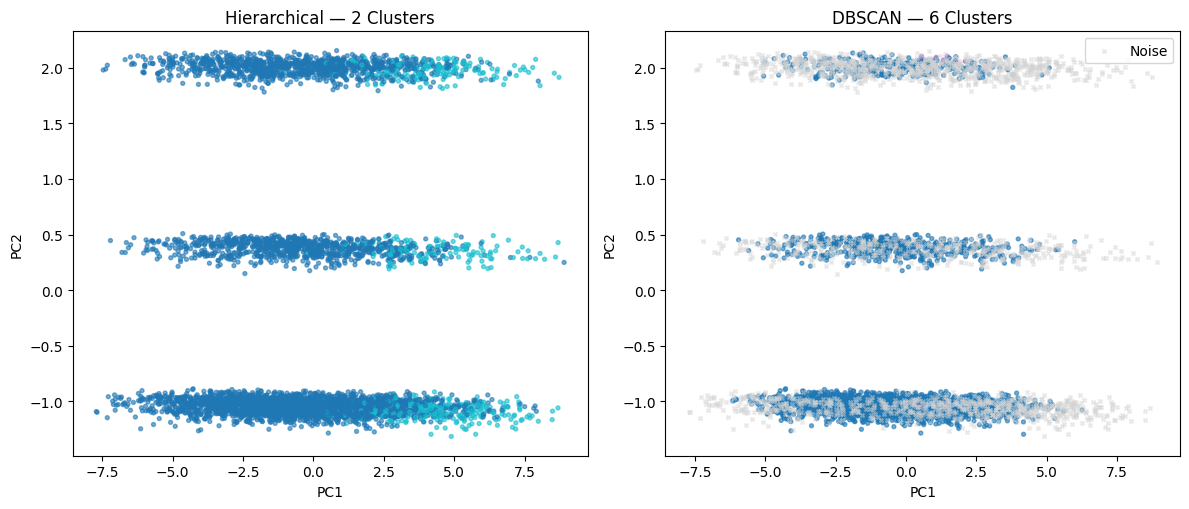

In [ ]:
coords_sub = X_pca_full[sub_idx]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2)
)

# Hierarchical
axes[0].scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    c=hc_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

axes[0].set_title(
    f"Hierarchical — {best_k} Clusters"
)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")


# DBSCAN
noise_mask = db_labels == -1

axes[1].scatter(
    coords_sub[~noise_mask, 0],
    coords_sub[~noise_mask, 1],
    c=db_labels[~noise_mask],
    cmap="tab10",
    s=8,
    alpha=0.6
)

axes[1].scatter(
    coords_sub[noise_mask, 0],
    coords_sub[noise_mask, 1],
    c="lightgray",
    s=8,
    alpha=0.5,
    marker="x",
    label="Noise"
)

axes[1].set_title(
    f"DBSCAN — {n_db_clusters} Clusters"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

axes[1].legend()

plt.tight_layout()

plt.show()

In [ ]:
df_out = df.copy()

df_out["KMeansCluster"] = km_labels

OUTPUT_PATH = (
    "/content/drive/MyDrive/"
    "placement_predict_with_clusters.csv"
)

df_out.to_csv(
    OUTPUT_PATH,
    index=False
)

print("DONE!")
print("\nOutput saved to:")
print(OUTPUT_PATH)

print("\nFinal dataset shape:")
print(df_out.shape)

df_out.head()

DONE!

Output saved to:
/content/drive/MyDrive/placement_predict_with_clusters.csv

Final dataset shape:
(50000, 22)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly,KMeansCluster
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,1,0,62.3,6.57,40.6,65.7,No,0,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,2,0,44.0,5.86,40.3,51.8,No,0,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2,1,73.8,7.50,73.6,67.9,No,1,0,1
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,6,2,100.0,9.41,98.7,NaN,No,1,0,1
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,4,2,90.8,9.24,83.1,100.0,No,1,0,1


In [ ]:
import matplotlib.pyplot as plt

plt.switch_backend("module://matplotlib_inline.backend_inline")

print("Plot display fixed!")

Plot display fixed!
